<a href="https://colab.research.google.com/github/SavindiPanditha/SE4050-Brain-Tumor-Classification/blob/feature%2FResNet50/Notebook/03_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ResNet50 - Brain Tumor MRI Classification
SE4050 Deep Learning Assignment | Transfer learning with ResNet50
Classes: 0 = Glioma, 1 = Meningioma, 2 = No Tumor, 3 = Pituitary

## 1. Environment and Configuration

In [1]:
# Connect Colab to Google Drive so we can read the shared dataset
from google.colab import drive
drive.mount('/content/drive')

PROJECT = "/content/drive/MyDrive/SE4050_DL_Assignment"
!ls "{PROJECT}/Dataset"

Mounted at /content/drive
dataset  dataset_config.py


In [2]:
PROJECT = "/content/drive/MyDrive/SE4050_DL_Assignment"
DATASET = f"{PROJECT}/Dataset/dataset"

# Check the folder structure
!ls "{DATASET}"
!ls "{DATASET}/splits"


splits	Testing  Training
test.csv  test.gsheet  train.csv  train.gsheet	val.csv


In [3]:
# Common training settings and helper functions: seed, image size, shared augmentation and the
# training strategy (max 10 epochs, early stopping on val_loss, best model saved). These match the
# proposed group common_config.py, so once it is finalized this cell becomes: from common_config import *
import os, random, time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
MAX_EPOCHS = 10
NUM_CLASSES = 4
CLASS_NAMES = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]   # index = label (0-3)
EARLY_STOPPING_PATIENCE = 3

def set_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

def build_augmentation():
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomRotation(0.05, seed=SEED),
        tf.keras.layers.RandomZoom(0.1, seed=SEED),
    ], name="augmentation")

def train_model(model, train_ds, val_ds, checkpoint_path, history_path):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
                                         restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss",
                                           save_best_only=True, verbose=1),
    ]
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=MAX_EPOCHS, callbacks=callbacks)
    minutes = (time.time() - start) / 60
    pd.DataFrame(history.history).to_csv(history_path, index=False)
    best = int(np.argmin(history.history["val_loss"])) + 1
    print(f"Training time: {minutes:.1f} min | Epochs run: {len(history.history['loss'])} | Best epoch: {best}")
    print(f"Best val_loss: {min(history.history['val_loss']):.4f} | "
          f"val_accuracy at best epoch: {history.history['val_accuracy'][best - 1]:.4f}")
    return history, minutes

set_seeds()
MODELS_DIR  = f"{PROJECT}/Trained Models"
RESULTS_DIR = f"{PROJECT}/Results/ResNet50"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("GPU:", tf.config.list_physical_devices("GPU"))
print("Image size:", IMG_SIZE, "| Batch:", BATCH_SIZE, "| Max epochs:", MAX_EPOCHS, "| Seed:", SEED)

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Image size: (224, 224) | Batch: 16 | Max epochs: 10 | Seed: 42


## 2. Dataset and Data Splits

In [4]:
#Load shared split CSV files
import pandas as pd

train_df = pd.read_csv(f"{DATASET}/splits/train.csv")
val_df   = pd.read_csv(f"{DATASET}/splits/val.csv")
test_df  = pd.read_csv(f"{DATASET}/splits/test.csv")

print(len(train_df), len(val_df), len(test_df))
print(train_df.columns.tolist())
print(train_df.head())

4480 1120 1600
['filepath', 'label', 'class_name']
                           filepath  label class_name
0  Training/pituitary/Tr-pi_135.jpg      3  Pituitary
1    Training/notumor/Tr-no_154.jpg      2   No Tumor
2     Training/glioma/Tr-gl_365.jpg      0     Glioma
3  Training/pituitary/Tr-pi_125.jpg      3  Pituitary
4     Training/glioma/Tr-gl_433.jpg      0     Glioma


In [5]:
#Copy images to local disk
LOCAL = "/content/data"
!mkdir -p {LOCAL}
!cp -r "{DATASET}/Training" "{DATASET}/Testing" {LOCAL}/
!ls {LOCAL}

Testing  Training


In [6]:
#Build full paths and verify files
import os

for df in (train_df, val_df, test_df):
    df["full_path"] = LOCAL + "/" + df["filepath"]

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = (~df["full_path"].apply(os.path.exists)).sum()
    print(f"{name}: {len(df)} images, missing files: {missing}")
    print(df["class_name"].value_counts().sort_index().to_dict())

train: 4480 images, missing files: 0
{'Glioma': 1120, 'Meningioma': 1120, 'No Tumor': 1120, 'Pituitary': 1120}
val: 1120 images, missing files: 0
{'Glioma': 280, 'Meningioma': 280, 'No Tumor': 280, 'Pituitary': 280}
test: 1600 images, missing files: 0
{'Glioma': 400, 'Meningioma': 400, 'No Tumor': 400, 'Pituitary': 400}


In [20]:
# Checks for data leakage: finds identical image files appearing in more than one split
# (train/val/test) by comparing file content hashes.
import hashlib

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {name: set(df["full_path"].apply(file_hash)) for name, df in
          [("train", train_df), ("val", val_df), ("test", test_df)]}

print("Train-Test duplicates:", len(hashes["train"] & hashes["test"]))
print("Val-Test duplicates:  ", len(hashes["val"] & hashes["test"]))
print("Train-Val duplicates: ", len(hashes["train"] & hashes["val"]))

Train-Test duplicates: 0
Val-Test duplicates:   0
Train-Val duplicates:  56


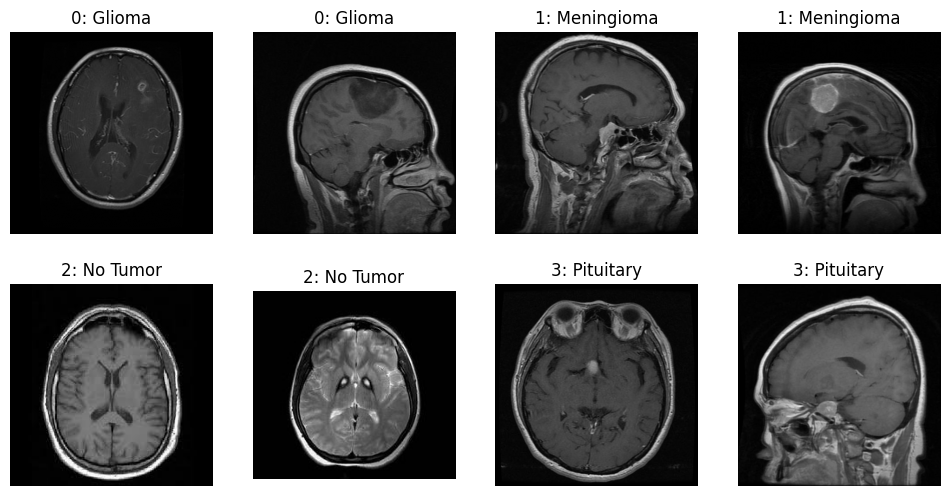

In [7]:
#Sample images per class
import matplotlib.pyplot as plt
from PIL import Image

sample = train_df.groupby("label").head(2).sort_values("label")
plt.figure(figsize=(12, 6))
for i, (_, row) in enumerate(sample.iterrows()):
    plt.subplot(2, 4, i + 1)
    plt.imshow(Image.open(row["full_path"]), cmap="gray")
    plt.title(f'{row["label"]}: {row["class_name"]}')
    plt.axis("off")
plt.show()

## 3. Image Preprocessing

In [8]:
# Builds the input pipeline: loads and resizes images to 224x224 and applies ResNet50's own
# preprocessing (no /255). Augmentation is inside the model, so all splits load the same way.
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return preprocess_input(img), label

def make_ds(df, shuffle):
    ds = tf.data.Dataset.from_tensor_slices((df["full_path"].values, df["label"].values))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df, shuffle=True)
val_ds   = make_ds(val_df, shuffle=False)
test_ds  = make_ds(test_df, shuffle=False)

x, y = next(iter(train_ds))
print("Batch shape:", x.shape, "| Labels:", y.numpy())

Batch shape: (16, 224, 224, 3) | Labels: [2 3 1 2 0 2 2 1 3 2 3 1 2 1 1 2]


## 4. ResNet50 Model

In [9]:
# ResNet50 pretrained on ImageNet with a frozen backbone. The shared augmentation layer comes first
# (active only during training), followed by a new head: pooling, dropout, 4-class softmax.
tf.keras.backend.clear_session()
set_seeds()

base = ResNet50(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = build_augmentation()(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs, name="resnet50_brain_mri")

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50_brain_mri"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 5. Model Training

In [10]:
# Stage 1: trains only the new head (backbone frozen): max 10 epochs, early stopping on val_loss
# (patience 3), best model and training history saved to Drive.
history1, stage1_minutes = train_model(
    model, train_ds, val_ds,
    checkpoint_path=f"{MODELS_DIR}/resnet50_stage1.keras",
    history_path=f"{RESULTS_DIR}/history_stage1.csv",
)

Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6599 - loss: 0.8980
Epoch 1: val_loss improved from None to 0.36937, saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Trained Models/resnet50_stage1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Trained Models/resnet50_stage1.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 46s 122ms/step - accuracy: 0.7679 - loss: 0.6147 - val_accuracy: 0.8580 - val_loss: 0.3694
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8512 - loss: 0.3795
Epoch 2: val_loss improved from 0.36937 to 0.31926, saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Trained Models/resnet50_stage1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Trained Models/resnet50_stage1.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 30s 97ms/step - accuracy: 0.8580 - loss: 0.3659 - val_accuracy: 0.8795 - val_loss: 0.3193
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accur

In [11]:
# Stage 2 (fine-tuning, extra experiment): loads the best Stage 1 model from Drive (works even after
# a runtime restart), unfreezes the conv5 block (BatchNorm stays frozen) and trains with lr = 1e-5.
model = tf.keras.models.load_model(f"{MODELS_DIR}/resnet50_stage1.keras")
base = model.get_layer("resnet50")

base.trainable = True
for layer in base.layers:
    layer.trainable = layer.name.startswith("conv5") and not isinstance(layer, tf.keras.layers.BatchNormalization)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
print("Trainable params:", sum(tf.keras.backend.count_params(w) for w in model.trainable_weights))

history2, stage2_minutes = train_model(
    model, train_ds, val_ds,
    checkpoint_path=f"{MODELS_DIR}/resnet50_finetuned.keras",
    history_path=f"{RESULTS_DIR}/history_stage2.csv",
)

Trainable params: 14961668
Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9093 - loss: 0.2417
Epoch 1: val_loss improved from None to 0.18551, saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Trained Models/resnet50_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SE4050_DL_Assignment/Trained Models/resnet50_finetuned.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 48s 138ms/step - accuracy: 0.9239 - loss: 0.2105 - val_accuracy: 0.9286 - val_loss: 0.1855
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9415 - loss: 0.1513
Epoch 2: val_loss did not improve from 0.18551
280/280 ━━━━━━━━━━━━━━━━━━━━ 35s 124ms/step - accuracy: 0.9455 - loss: 0.1411 - val_accuracy: 0.9321 - val_loss: 0.1864
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9615 - loss: 0.1054
Epoch 3: val_loss did not improve from 0.18551
280/280 ━━━━━━━━━━━━━━━━━━━━ 42s 127ms/step - accuracy: 0.9643 - loss: 0.1033 - val_accuracy: 0.9250 - val_

## 6. Training Results

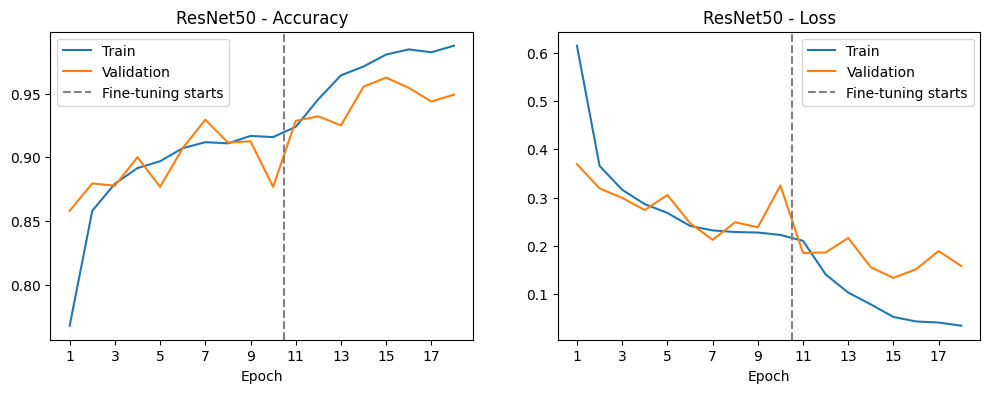

In [13]:
# Plots accuracy and loss from the saved history files (works after a restart). If Stage 2 has run,
# both stages are shown with a dashed line where fine-tuning starts. Epochs are numbered from 1.
h1 = pd.read_csv(f"{RESULTS_DIR}/history_stage1.csv")
stage2_file = f"{RESULTS_DIR}/history_stage2.csv"
h = pd.concat([h1, pd.read_csv(stage2_file)], ignore_index=True) if os.path.exists(stage2_file) else h1
epochs = range(1, len(h) + 1)

plt.figure(figsize=(12, 4))
for i, metric in enumerate(["accuracy", "loss"]):
    plt.subplot(1, 2, i + 1)
    plt.plot(epochs, h[metric], label="Train")
    plt.plot(epochs, h[f"val_{metric}"], label="Validation")
    if len(h) > len(h1):
        plt.axvline(len(h1) + 0.5, color="gray", linestyle="--", label="Fine-tuning starts")
    plt.title(f"ResNet50 - {metric.capitalize()}")
    plt.xlabel("Epoch"); plt.legend()
    plt.xticks(range(1, len(h) + 1, 2))

plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Test Evaluation

In [14]:
# Evaluates the final model (fine-tuned, chosen by lowest validation loss) on the unseen test set.
final_model = tf.keras.models.load_model(f"{MODELS_DIR}/resnet50_finetuned.keras")
test_loss, test_accuracy = final_model.evaluate(test_ds, verbose=1)

print(f"\nFine-tuned ResNet50")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.9162 - loss: 0.5727

Fine-tuned ResNet50
Test loss: 0.5727
Test accuracy: 0.9162
Test accuracy: 91.62%


In [16]:
# Evaluates the Stage 1 (frozen backbone) model on the same test set, for a fair comparison
# with group models that were not fine-tuned.
stage1_model = tf.keras.models.load_model(f"{MODELS_DIR}/resnet50_stage1.keras")
s1_loss, s1_accuracy = stage1_model.evaluate(test_ds, verbose=1)

print(f"\nStage 1 ResNet50 (frozen backbone)")
print(f"Test loss: {s1_loss:.4f}")
print(f"Test accuracy: {s1_accuracy:.4f}")
print(f"Test accuracy: {s1_accuracy * 100:.2f}%")

100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.8806 - loss: 0.4249

Stage 1 ResNet50 (frozen backbone)
Test loss: 0.4249
Test accuracy: 0.8806
Test accuracy: 88.06%


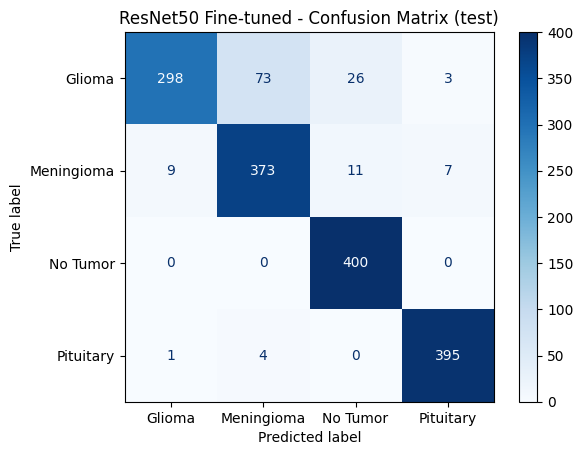

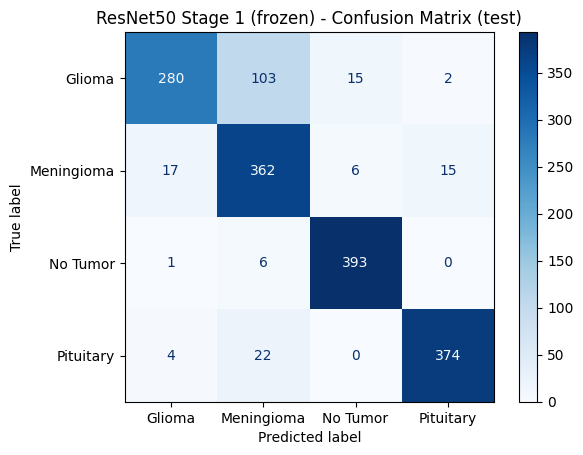

In [22]:
# Predicts the test set with both models and plots one confusion matrix per model (counts).
# The predictions are reused in the Class-wise Analysis section.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = test_df["label"].values
test_probs = {
    "finetuned": final_model.predict(test_ds, verbose=0),
    "stage1": stage1_model.predict(test_ds, verbose=0),
}

for name, tag in [("Fine-tuned", "finetuned"), ("Stage 1 (frozen)", "stage1")]:
    cm = confusion_matrix(y_true, test_probs[tag].argmax(axis=1))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap="Blues")
    plt.title(f"ResNet50 {name} - Confusion Matrix (test)")
    plt.savefig(f"{RESULTS_DIR}/confusion_matrix_{tag}_test.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. Class-wise Analysis

In [23]:
# Class-wise test results for each model: per-class precision, recall and F1 in %,
# with metrics and per-image predictions saved for the group comparison.
import json
from sklearn.metrics import classification_report, roc_auc_score

def class_wise_analysis(model, name, tag):
    probs = test_probs[tag]
    preds = probs.argmax(axis=1)
    report = classification_report(y_true, preds, target_names=CLASS_NAMES, output_dict=True)

    table = pd.DataFrame({c: report[c] for c in CLASS_NAMES}).T[["precision", "recall", "f1-score"]] * 100
    table.columns = ["Precision (%)", "Recall (%)", "F1-score (%)"]
    table["Test images"] = [int(report[c]["support"]) for c in CLASS_NAMES]
    print(f"\n{name} - class-wise results on the test set")
    display(table.round(2))

    metrics = {
        "model": f"ResNet50_{tag}", "split": "test",
        "accuracy": report["accuracy"],
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "roc_auc_ovr_macro": roc_auc_score(y_true, probs, multi_class="ovr", average="macro"),
        "per_class": {c: report[c] for c in CLASS_NAMES},
        "total_params": int(model.count_params()),
    }
    with open(f"{RESULTS_DIR}/metrics_{tag}_test.json", "w") as f:
        json.dump(metrics, f, indent=2)

    out = test_df[["filepath", "label"]].copy()
    out["pred"] = preds
    for i, c in enumerate(CLASS_NAMES):
        out[f"prob_{c}"] = probs[:, i]
    out.to_csv(f"{RESULTS_DIR}/predictions_{tag}_test.csv", index=False)
    return metrics

finetuned_metrics = class_wise_analysis(final_model, "Fine-tuned", "finetuned")
stage1_metrics = class_wise_analysis(stage1_model, "Stage 1 (frozen)", "stage1")


Fine-tuned - class-wise results on the test set


,Precision (%),Recall (%),F1-score (%),Test images
Glioma,96.75,74.50,84.18,400
Meningioma,82.89,93.25,87.76,400
No Tumor,91.53,100.00,95.58,400
Pituitary,97.53,98.75,98.14,400



Stage 1 (frozen) - class-wise results on the test set


,Precision (%),Recall (%),F1-score (%),Test images
Glioma,92.72,70.00,79.77,400
Meningioma,73.43,90.50,81.08,400
No Tumor,94.93,98.25,96.56,400
Pituitary,95.65,93.50,94.56,400
